## This Python workflow will walk you through the steps to Perform DEM co-registration, following the workflow of Shean et al. (2023), an implementation of Nuth and Kääb (2011)

The workflow for Shean et al. (2023) DEM co-registration is found here: https://github.com/dshean/demcoreg

In [1]:
# Import required packages
import argparse
import os
import subprocess
import sys
import zipfile
import earthaccess
import folium
from folium.raster_layers import ImageOverlay
import geopandas as gpd
from osgeo import gdal
import numpy as np
import pygeotools
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pyproj import CRS
import demcoreg
import rioxarray as rxr
import xarray as xr
import imview
import matplotlib.pyplot as plt

DEM co-registration: 
Here we follow the workflow provided by Shean et al. (2023), derived from the Nuth and Kääb (2011) method, here: https://github.com/dshean/demcoreg/blob/master/docs/beginners_doc.md

The code below references Shean's 'dem_align.py - robust raster DEM co-registration' script, which housed here in the coreg_directory

** 

We use the DGA glacier shapefiles, rather than RGI v6.0, as the glacier mask. If you would like to do the same: 
<cd src/demcoreg>
<git apply use_nevados_shapefile.patch>

Then: 
<dem_align.py -mode nuth -mask_list glaciers -- \
  /Users/milliespencer/Desktop/70_Years_MB_Nevados/NEWDEMs_to_coregister_nevados/SRTM_DEMprojected.tif \
  /Users/milliespencer/Desktop/70_Years_MB_Nevados/NEWDEMs_to_coregister_nevados/CerroBlanco_DEMprojected.tif>

Code Format: 
Reference: /Users/milliespencer/Desktop/70_Years_MB_Nevados/NEWDEMs_to_coregister_nevados/SRTM_DEMprojected.tif
Source: /Users/milliespencer/Desktop/70_Years_MB_Nevados/NEWDEMs_to_coregister_nevados/CerroBlanco_DEMprojected.tif #switch out for each DEM you want co-registered to the Reference DEM 
Mode: nuth
Output: /Users/milliespencer/Desktop/70_Years_MB_Nevados/NEWDEMs_to_coregister_nevados/CerroBlanco_DEMprojected_dem_align/CerroBlanco_DEMprojected_SRTM_DEMprojected

In [9]:
#trying new approach where I mask everything but stable areas 
# manually drew stable ground areas in Google Earth Pro (saved as individual .kmz files)
import pandas as pd
import geopandas as gpd
import glob

# Path to your KML files of stable ground areas surrounding the glaciers 
kmz_files = glob.glob("/Users/milliespencer/Desktop/stable_areas_NevdeC/*.kmz")

# Read and combine all KMLs
gdf_list = [gpd.read_file(kmz, driver='KMZ') for kmz in kmz_files]
combined = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True))

# Save to shapefile
combined.to_file("combined_mask_output.shp")

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_7908/2766115354.py:15: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  combined.to_file("combined_mask_output.shp")
/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'description' to 'descriptio'
  ogr_write(
/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field timestamp create as date field, though DateTime requested.
  ogr_write(
/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field begin create as date field, though DateTime requested.
  ogr_write(
/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field end create as date field, though DateTime requested.
  ogr_write(
/Users/milliesp

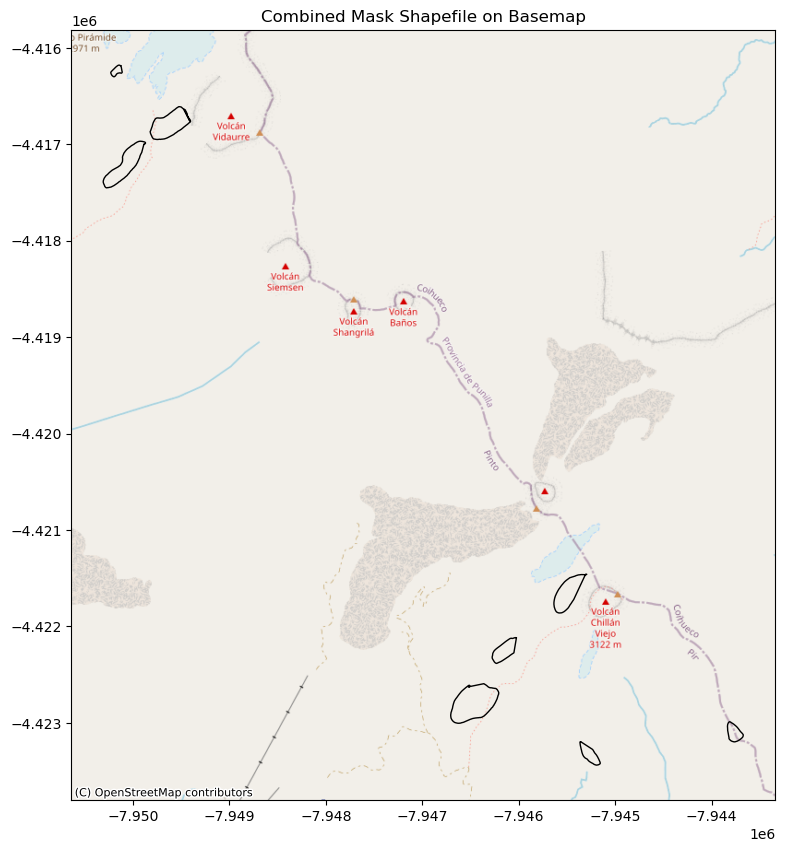

In [10]:
#plot to make sure shapefiles were created properly
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx  # for basemaps

# Load your combined shapefile
gdf = gpd.read_file("combined_mask_output.shp")

# Reproject to Web Mercator (required for basemaps like OpenStreetMap)
gdf = gdf.to_crs(epsg=3857)

# Plot
ax = gdf.plot(figsize=(10, 10), edgecolor='black', facecolor='none')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.title("Combined Mask Shapefile on Basemap")
plt.show()


## How to initiate co-registration: 
Loading the DEMs, reprojecting the DEMs to the same spatial reference system, and calculating slope and aspect to use in the co-registration process. 

* if you're jumping in at this step, and your DEMs aren't in the same projection, use this command in your terminal to reproject a DEM: < gdalwarp -r cubic -t_srs EPSG:XXXXX > (XXXXX = projection of your choosing, here we use 32719)
* then run: < dem_align.py -mode nuth dem1.tif dem2.tif > to co-register your DEMs. Here, dem2 (source) is co-registered to dem1 (reference). This is the traditional function, which allows you to specify specific pre-loaded masks (e.g. RGI glacier areas)
* the code will output your coregistered dem2, as well as summary statistics and additional files. For our purposes, the file name ending with *_align.tif is the outputted co-registered DEM we're interested in using. 